# DBSCAN

DBSCAN, full name Density-Based Spatial Clustering of Applications with Noise (simplified to Density-Based Clustering).

It works by defining density using two parameters: `epsilon` (the radius) and `min_samples` (the minimum points in that radius). DBSCAN excels at finding non-spherical clusters and handling datasets with noisy data, unlike methods like k-means

Consider this simple height and weight dataset

Text(0, 0.5, 'Height (cm)')

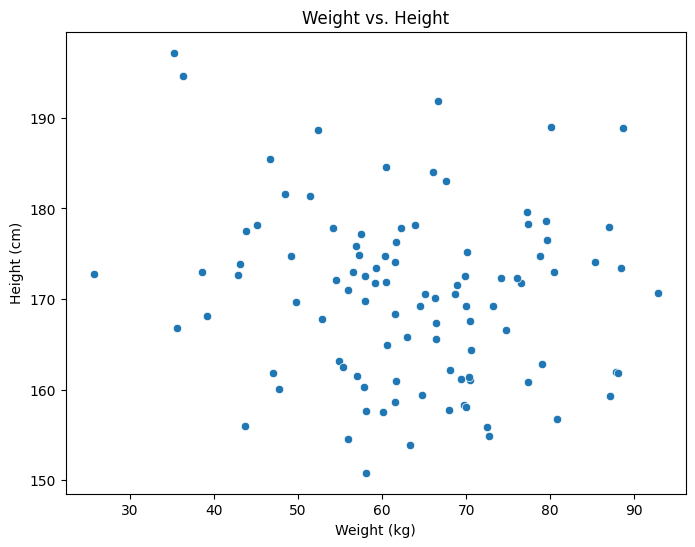

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Reproducibility
np.random.seed(42)

# Generate data
n_samples = 100

weights = np.random.normal(loc=65, scale=15, size=n_samples)    # kg
heights = np.random.normal(loc=170, scale=10, size=n_samples)   # cm

# Create DataFrame
df = pd.DataFrame({'Weight_kg': weights, 'Height_cm': heights})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm')
plt.title('Weight vs. Height')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')

Text(0, 0.5, 'Frequency')

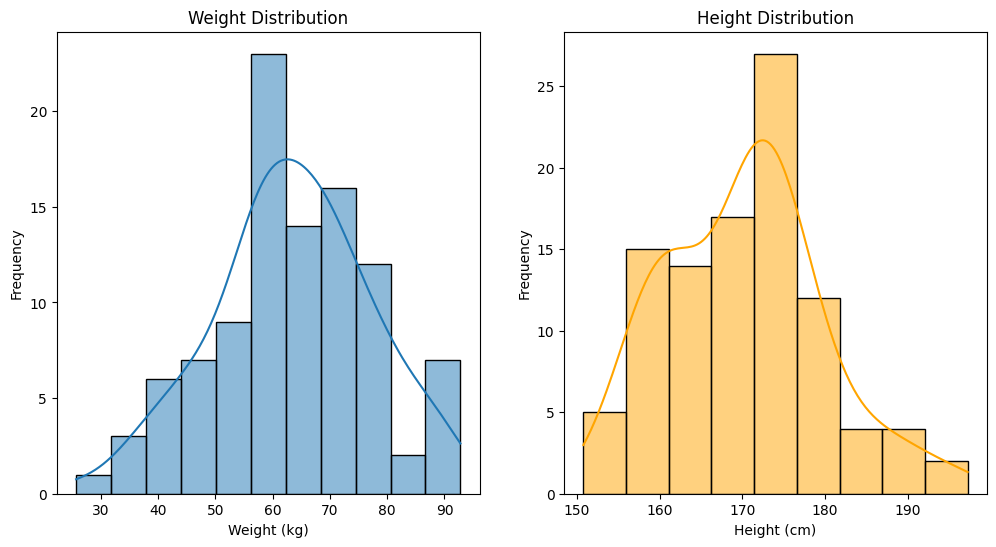

In [ ]:
# Distribution plot (reference only)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# Weight distribution
sns.histplot(data=df, x='Weight_kg', kde=True, ax=axs[0])
axs[0].set_title('Weight Distribution')
axs[0].set_xlabel('Weight (kg)')
axs[0].set_ylabel('Frequency')

# Height distribution
sns.histplot(data=df, x='Height_cm', kde=True, ax=axs[1], color='orange')
axs[1].set_title('Height Distribution')
axs[1].set_xlabel('Height (cm)')
axs[1].set_ylabel('Frequency')

In [ ]:
# Standardization: Useful for clustering
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
scaled_df = scaler.fit_transform(df)

**K-Means Clustering**: Partitioned data into clusters using central points called centroids and Euclidean distance

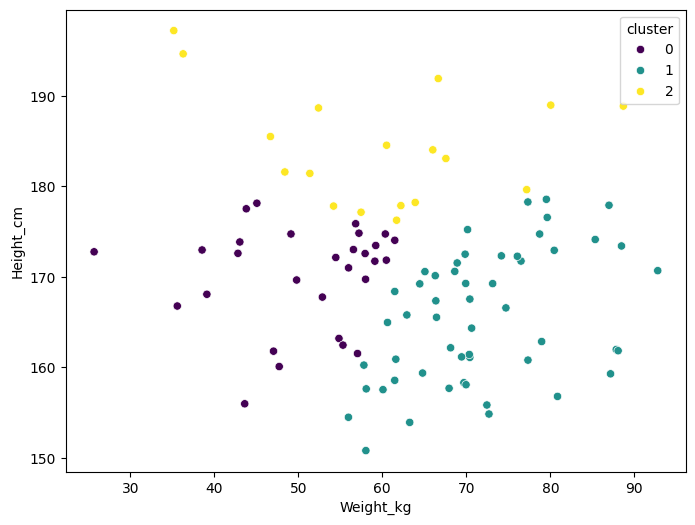

In [ ]:
from sklearn.cluster import KMeans

# Initialize the KMeans
model = KMeans(n_clusters=3, random_state=42)

# Fit the model
model.fit(scaled_df)

# Visualize the fit data
plt.figure(figsize=(8, 6))
df['cluster'] = model.labels_
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm',
                hue='cluster', palette='viridis')
plt.show()

DBSCAN starts with raw, unclustered data and uses the density of points to determine how clusters should be formed. Regions with high density become clusters, while low-density regions are treated as outliers.

In DBSCAN, ε (epsilon) is defined as the radius of a circle centered at a data point. This radius determines how close other points must be to be considered neighbors.

For each point in the dataset, DBSCAN counts the number of points that lie within its ε-radius neighborhood. Conceptually, a circle is drawn around the point, with the red point representing the center of the circle.

All points that fall inside or on the boundary of this circle are considered neighboring points.

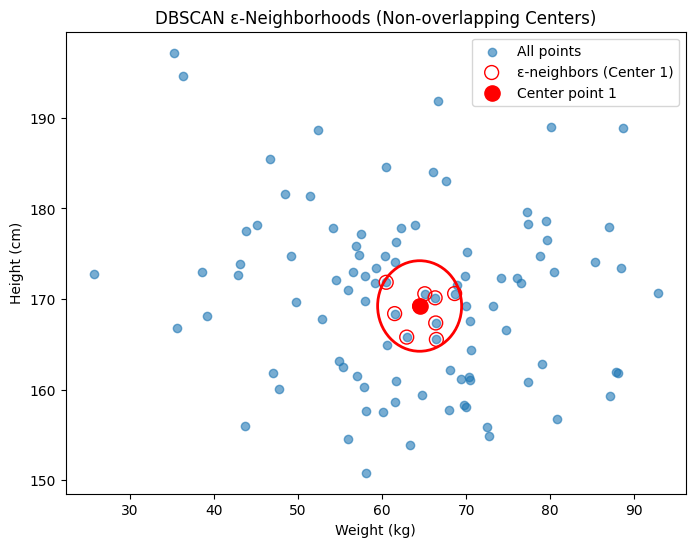

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt

# Compute dataset center (mean)
mean_weight = df['Weight_kg'].mean()
mean_height = df['Height_cm'].mean()

# Distance to dataset center
distances_to_center = np.sqrt(
    (df['Weight_kg'] - mean_weight)**2 +
    (df['Height_cm'] - mean_height)**2
)

# First center point
center_idx = distances_to_center.idxmin()
center_point = df.loc[center_idx]

eps = 5  # radius

# Distances from first center
distances_1 = np.sqrt(
    (df['Weight_kg'] - center_point['Weight_kg'])**2 +
    (df['Height_cm'] - center_point['Height_cm'])**2
)

within_eps_1 = distances_1 <= eps


# Plot
plt.figure(figsize=(8, 6))

# All points
plt.scatter(df['Weight_kg'], df['Height_cm'],
            alpha=0.6, label='All points')

# ε-neighbors of first center
plt.scatter(df.loc[within_eps_1, 'Weight_kg'],
            df.loc[within_eps_1, 'Height_cm'],
            facecolors='none', edgecolors='red',
            s=100, label='ε-neighbors (Center 1)')


# Center points
plt.scatter(center_point['Weight_kg'],
            center_point['Height_cm'],
            color='red', s=120, label='Center point 1')


# Draw ε-circles
circle1 = Circle(
    (center_point['Weight_kg'], center_point['Height_cm']),
    eps, fill=False, edgecolor='red', linewidth=2
)


plt.gca().add_patch(circle1)

# Labels
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.title('DBSCAN ε-Neighborhoods (Non-overlapping Centers)')
plt.legend()

plt.show()

Every point in the dataset acts as the center of its own circle with the same fixed radius ε. As a result, the number of circles equals the number of data points. However, because the distribution of points in the data varies, the number of neighboring points within each circle differs from point to point.

Points located in dense regions will have many neighbors inside their ε-radius, while points in sparse regions will have few or no neighbors. This variation in local density is what DBSCAN uses to distinguish core points, border points, and noise, and ultimately to form clusters based on dense regions of the data.

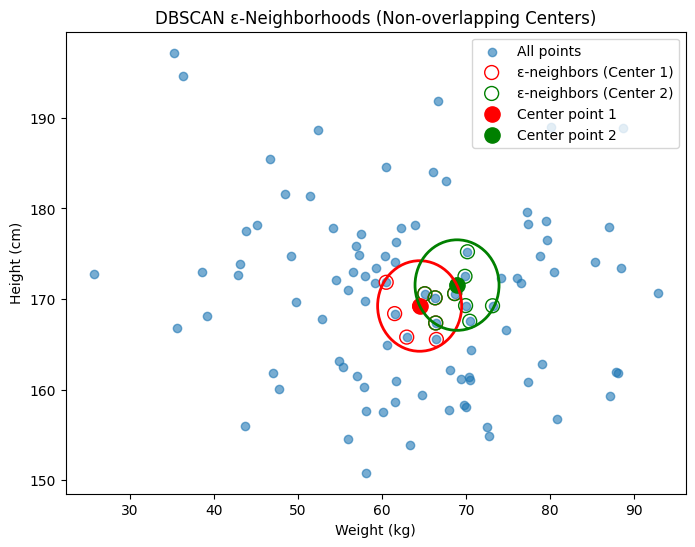

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt

# Compute dataset center (mean)
mean_weight = df['Weight_kg'].mean()
mean_height = df['Height_cm'].mean()

# Distance to dataset center
distances_to_center = np.sqrt(
    (df['Weight_kg'] - mean_weight)**2 +
    (df['Height_cm'] - mean_height)**2
)

# First center point
center_idx = distances_to_center.idxmin()
center_point = df.loc[center_idx]

eps = 5  # radius

# Distances from first center
distances_1 = np.sqrt(
    (df['Weight_kg'] - center_point['Weight_kg'])**2 +
    (df['Height_cm'] - center_point['Height_cm'])**2)

within_eps_1 = distances_1 <= eps

# Select a nearby point OUTSIDE the first ε-circle
neighbor_idx = distances_1[distances_1 > eps].idxmin()
neighbor_point = df.loc[neighbor_idx]

# Distances from second center
distances_2 = np.sqrt(
    (df['Weight_kg'] - neighbor_point['Weight_kg'])**2 +
    (df['Height_cm'] - neighbor_point['Height_cm'])**2)

within_eps_2 = distances_2 <= eps

# Plot
plt.figure(figsize=(8, 6))

# All points
plt.scatter(df['Weight_kg'], df['Height_cm'],
            alpha=0.6, label='All points')

# ε-neighbors of first center
plt.scatter(df.loc[within_eps_1, 'Weight_kg'],
            df.loc[within_eps_1, 'Height_cm'],
            facecolors='none', edgecolors='red',
            s=100, label='ε-neighbors (Center 1)')

# ε-neighbors of second center
plt.scatter(df.loc[within_eps_2, 'Weight_kg'],
            df.loc[within_eps_2, 'Height_cm'],
            facecolors='none', edgecolors='green',
            s=100, label='ε-neighbors (Center 2)')

# Center points
plt.scatter(center_point['Weight_kg'],
            center_point['Height_cm'],
            color='red', s=120, label='Center point 1')

plt.scatter(neighbor_point['Weight_kg'],
            neighbor_point['Height_cm'],
            color='green', s=120, label='Center point 2')

# Draw ε-circles
circle1 = Circle(
    (center_point['Weight_kg'], center_point['Height_cm']),
    eps, fill=False, edgecolor='red', linewidth=2)

circle2 = Circle(
    (neighbor_point['Weight_kg'], neighbor_point['Height_cm']),
    eps, fill=False, edgecolor='green', linewidth=2)

plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)

# Labels
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.title('DBSCAN ε-Neighborhoods (Non-overlapping Centers)')
plt.legend()

plt.show()

If 8 other points fall inside a point’s ε-neighborhood (plus the point itself, making 9 total points), and `minPts = 9`, then this point is classified as a **core point**.

The remaining 8 neighbor points can possibly be:

* They could be core points if they also have at least minPts points within their own ε-radius neighborhood.
* They could be border points if they have fewer than minPts neighbors, but still lie within the ε-radius of another core point.
* They could even be classified as noise if they have fewer than minPts neighbors and are not density-reachable from any core point.

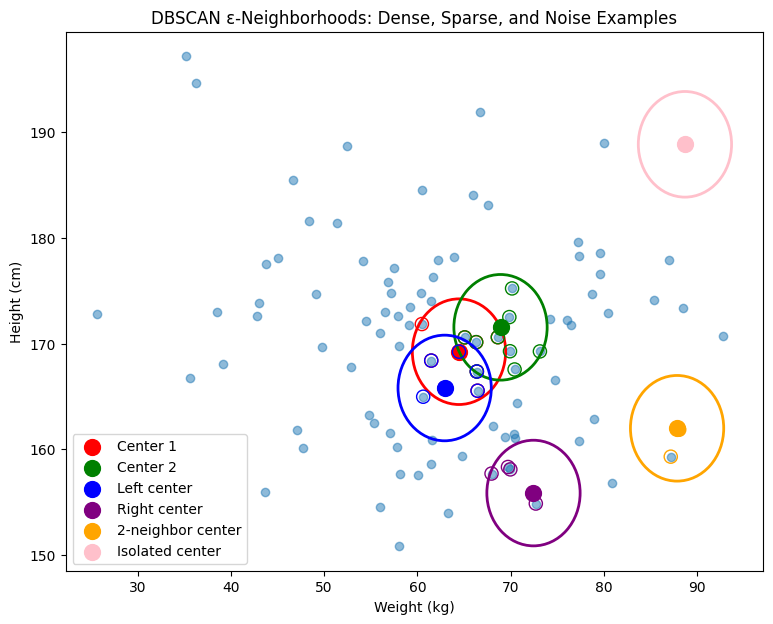

In [ ]:
def count_neighbors(center):
    d = np.sqrt(
        (df['Weight_kg'] - center['Weight_kg'])**2 +
        (df['Height_cm'] - center['Height_cm'])**2)
    return (d <= eps).sum() - 1  # exclude itself


# (1) Left of both previous centers
left_center = df[df['Weight_kg'] <
                 min(center_point['Weight_kg'],
                     neighbor_point['Weight_kg'])].iloc[0]

# (2) Right of both previous centers
right_center = df[df['Weight_kg'] >
                  max(center_point['Weight_kg'],
                      neighbor_point['Weight_kg'])].iloc[0]

# (3) Exactly two neighbors
two_neighbor_idx = [
    idx for idx in df.index
    if count_neighbors(df.loc[idx]) == 2
][0]
two_neighbor_center = df.loc[two_neighbor_idx]

# (4) No neighbors
no_neighbor_idx = [
    idx for idx in df.index
    if count_neighbors(df.loc[idx]) == 0][0]

no_neighbor_center = df.loc[no_neighbor_idx]


extra_centers = [('Left center', left_center, 'blue'),
    ('Right center', right_center, 'purple'),
    ('2-neighbor center', two_neighbor_center, 'orange'),
    ('Isolated center', no_neighbor_center, 'pink')]


# ---------- Plot ----------
plt.figure(figsize=(9, 7))

# All points
plt.scatter(df['Weight_kg'], df['Height_cm'], alpha=0.5)

# Existing centers
base_centers = [
    ('Center 1', center_point, 'red'),
    ('Center 2', neighbor_point, 'green')
]

for label, c, color in base_centers + extra_centers:
    # distances
    d = np.sqrt(
        (df['Weight_kg'] - c['Weight_kg'])**2 +
        (df['Height_cm'] - c['Height_cm'])**2
    )
    within = d <= eps

    # neighbors
    plt.scatter(df.loc[within, 'Weight_kg'],
                df.loc[within, 'Height_cm'],
                facecolors='none', edgecolors=color, s=90)

    # center
    plt.scatter(c['Weight_kg'], c['Height_cm'],
                color=color, s=130, label=label)

    # ε-circle
    plt.gca().add_patch(
        Circle((c['Weight_kg'], c['Height_cm']),
               eps, fill=False, edgecolor=color, linewidth=2)
    )


# Labels
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.title('DBSCAN ε-Neighborhoods: Dense, Sparse, and Noise Examples')
plt.legend()
plt.show()

Among the six points, four are core points. The remaining two points are not core points because the number of points within their ε-neighborhood is less than 4. At this stage, we determine whether these two points should be classified as border points or noise points.

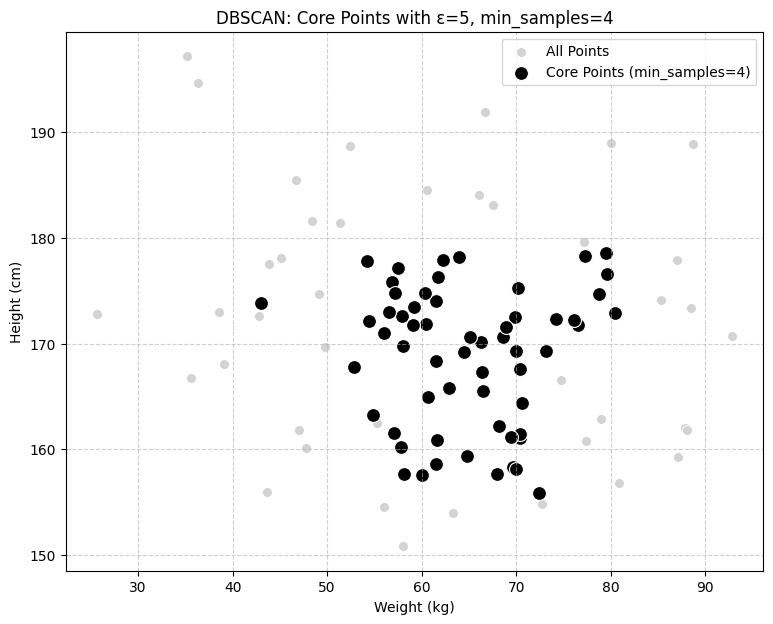

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define parameters
eps = 5  # From previous cells
min_samples = 4

# Function to count neighbors within eps for a given center point
def count_neighbors_for_point(point_idx, df_data, epsilon):
    center = df_data.loc[point_idx]
    distances = np.sqrt(
        (df_data['Weight_kg'] - center['Weight_kg'])**2 +
        (df_data['Height_cm'] - center['Height_cm'])**2
    )
    # Exclude the point itself when counting neighbors
    return (distances <= epsilon).sum() - 1

# Identify core points
core_points_indices = []
for i in range(len(df)):
    if count_neighbors_for_point(i, df, eps) >= min_samples:
        core_points_indices.append(i)

core_points_df = df.loc[core_points_indices]

# Plotting
plt.figure(figsize=(9, 7))

# Plot all points as background
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray',
                s=50, label='All Points')

# Plot core points in black
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm',
                color='black', s=100,
                label=f'Core Points (min_samples={min_samples})')

plt.title(f'DBSCAN: Core Points with ε={eps}, min_samples={min_samples}')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

A key aspect of DBSCAN is how it expands clusters from core points. If a core point is within the ε-neighborhood of another core point, they belong to the same cluster. This process continues, forming chains of density-reachable core points.

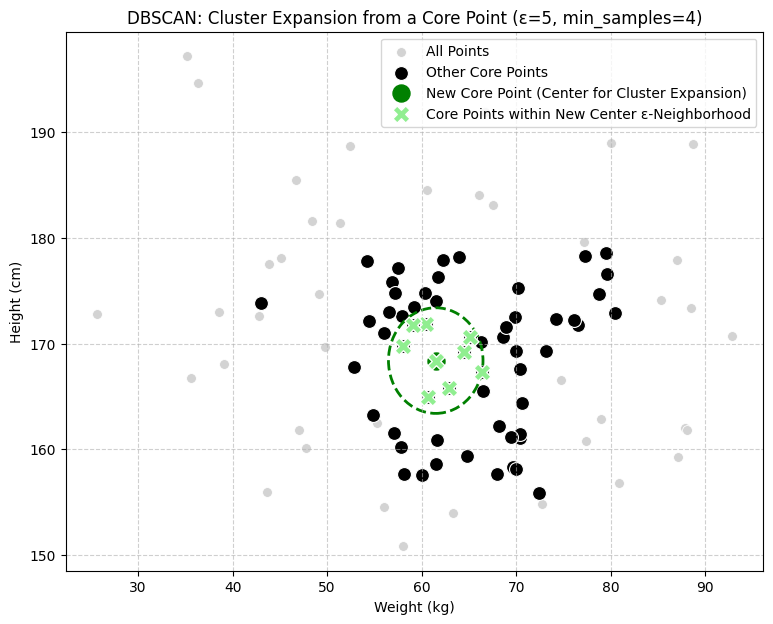

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt

# Reuse eps and df from previous cells

# Select a new core point from the identified core_points_df
# Let's pick an un-clustered core point if possible or just another one.
# Using df.loc[0] as a new core point for demonstration, which
# is in core_points_df
new_center_point = df.loc[core_points_indices[2]] # Using a core point

# Calculate distances from this new center point
distances_new_center = np.sqrt(
    (df['Weight_kg'] - new_center_point['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point['Height_cm'])**2
)

# Identify points within the epsilon radius of the new center
within_eps_new_center = distances_new_center <= eps

# Identify core points that are also within the epsilon radius of the new center
# This simulates density-reachability between core points
overlapping_core_points_indices = [idx for idx in core_points_indices
                                   if within_eps_new_center[idx]]
overlapping_core_points_df = df.loc[overlapping_core_points_indices]

# Plotting
plt.figure(figsize=(9, 7))

# All points (light gray background)
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray',
                s=50, label='All Points')

# Plot existing core points (black)
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm',
                color='black', s=100, label='Other Core Points')

# Plot the new selected core point (green)
plt.scatter(new_center_point['Weight_kg'], new_center_point['Height_cm'],
            color='green', s=150, zorder=5,
            label='New Core Point (Center for Cluster Expansion)')

# Draw the epsilon circle around the new center point (green)
circle_new = Circle(
    (new_center_point['Weight_kg'], new_center_point['Height_cm']),
    eps, fill=False, edgecolor='green', linewidth=2, linestyle='--'
)
plt.gca().add_patch(circle_new)

# Highlight the core points that are within the new center's
# epsilon radius (light green)
sns.scatterplot(data=overlapping_core_points_df, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6, label='Core Points within New Center ε-Neighborhood')


plt.title(f'DBSCAN: Cluster Expansion from a Core Point (ε={eps}, min_samples={min_samples})')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Then the core points close to the growing cluster join it.

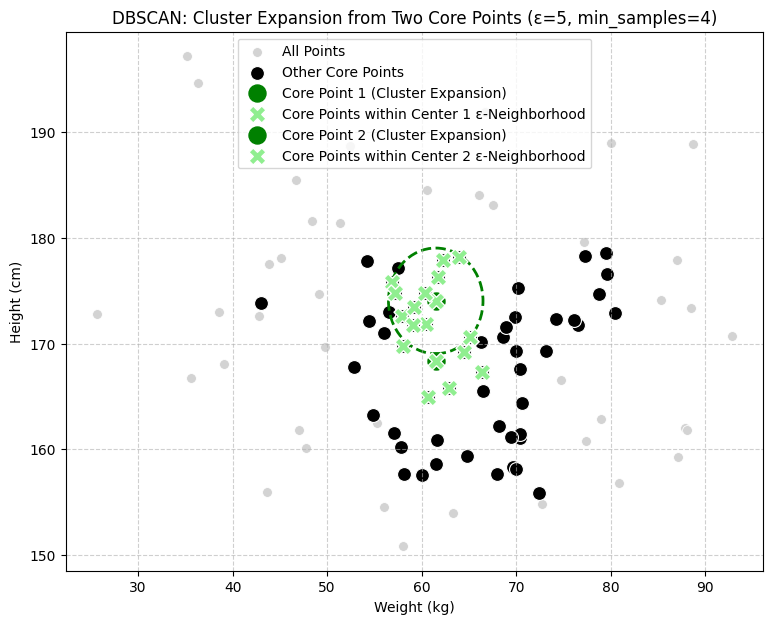

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt


# Select new core points from the identified core_points_df
# Let's pick un-clustered core points if possible or just another one.
new_center_point = df.loc[core_points_indices[2]]
new_center_point2 = df.loc[core_points_indices[3]]

# Calculate distances from the first new center point
distances_new_center_1 = np.sqrt(
    (df['Weight_kg'] - new_center_point['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point['Height_cm'])**2
)

# Calculate distances from the second new center point
distances_new_center_2 = np.sqrt(
    (df['Weight_kg'] - new_center_point2['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point2['Height_cm'])**2
)


# Identify points within the epsilon radius of the first center
within_eps_new_center_1 = distances_new_center_1 <= eps

# Identify core points that are also within the epsilon radius of the first center
overlapping_core_points_indices_1 = [idx for idx in core_points_indices
                                   if within_eps_new_center_1[idx]]
overlapping_core_points_df_1 = df.loc[overlapping_core_points_indices_1]

# Identify points within the epsilon radius of the second center
within_eps_new_center_2 = distances_new_center_2 <= eps

# Identify core points that are also within the epsilon radius of the second center
overlapping_core_points_indices_2 = [idx for idx in core_points_indices
                                   if within_eps_new_center_2[idx]]
overlapping_core_points_df_2 = df.loc[overlapping_core_points_indices_2]

# Plotting
plt.figure(figsize=(9, 7))

# All points (light gray background)
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray',
                s=50, label='All Points')

# Plot existing core points (black)
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm',
                color='black', s=100, label='Other Core Points')

# Plot the first new selected core point (green)
plt.scatter(new_center_point['Weight_kg'], new_center_point['Height_cm'],
            color='green', s=150, zorder=5,
            label='Core Point 1 (Cluster Expansion)')

# Highlight the core points that are within the first new center's
# epsilon radius (light green)
sns.scatterplot(data=overlapping_core_points_df_1, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6, label='Core Points within Center 1 ε-Neighborhood')

# Plot the second new selected core point (blue)
plt.scatter(new_center_point2['Weight_kg'], new_center_point2['Height_cm'],
            color='green', s=150, zorder=5,
            label='Core Point 2 (Cluster Expansion)')

# Draw the epsilon circle around the second new center point (blue)
circle_new_2 = Circle(
    (new_center_point2['Weight_kg'], new_center_point2['Height_cm']),
    eps, fill=False, edgecolor='green', linewidth=2, linestyle='--'
)
plt.gca().add_patch(circle_new_2)

# Highlight the core points that are within the second new center's
# epsilon radius (lightgreen)
sns.scatterplot(data=overlapping_core_points_df_2, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6, label='Core Points within Center 2 ε-Neighborhood')


plt.title(f'DBSCAN: Cluster Expansion from Two Core Points (ε={eps}, min_samples={min_samples})')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Extend it to close by Core Points

<Axes: xlabel='Weight_kg', ylabel='Height_cm'>

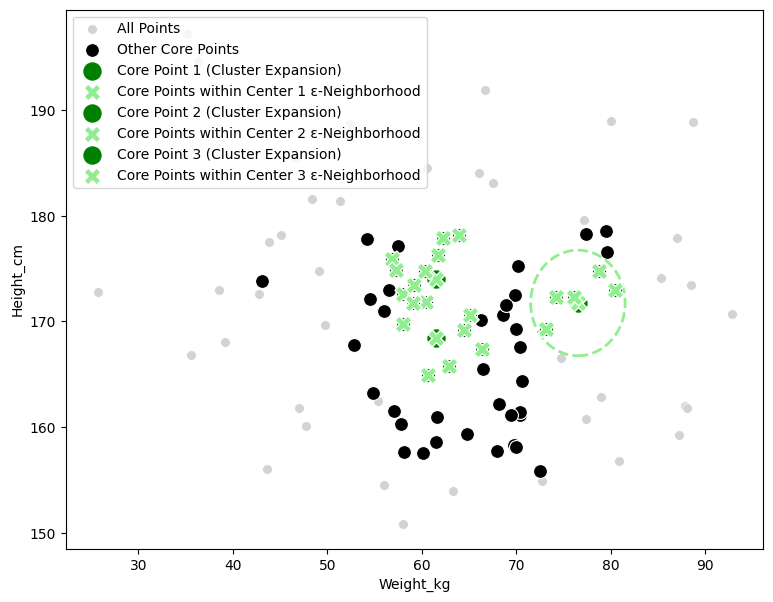

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt


# Select new core points from the identified core_points_df
# Let's pick un-clustered core points if possible or just another one.
new_center_point = df.loc[core_points_indices[2]]
new_center_point2 = df.loc[core_points_indices[3]]

# Calculate distances from the first new center point
distances_new_center_1 = np.sqrt(
    (df['Weight_kg'] - new_center_point['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point['Height_cm'])**2
)

# Calculate distances from the second new center point
distances_new_center_2 = np.sqrt(
    (df['Weight_kg'] - new_center_point2['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point2['Height_cm'])**2
)


# Identify points within the epsilon radius of the first center
within_eps_new_center_1 = distances_new_center_1 <= eps

# Identify core points that are also within the epsilon radius of the first center
overlapping_core_points_indices_1 = [idx for idx in core_points_indices
                                   if within_eps_new_center_1[idx]]
overlapping_core_points_df_1 = df.loc[overlapping_core_points_indices_1]

# Identify points within the epsilon radius of the second center
within_eps_new_center_2 = distances_new_center_2 <= eps

# Identify core points that are also within the epsilon radius of the second center
overlapping_core_points_indices_2 = [idx for idx in core_points_indices
                                   if within_eps_new_center_2[idx]]
overlapping_core_points_df_2 = df.loc[overlapping_core_points_indices_2]

# Plotting
plt.figure(figsize=(9, 7))

# All points (light gray background)
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray',
                s=50, label='All Points')

# Plot existing core points (black)
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm',
                color='black', s=100, label='Other Core Points')

# Plot the first new selected core point (green)
plt.scatter(new_center_point['Weight_kg'], new_center_point['Height_cm'],
            color='green', s=150, zorder=5,
            label='Core Point 1 (Cluster Expansion)')

# Highlight the core points that are within the first new center's
# epsilon radius (light green)
sns.scatterplot(data=overlapping_core_points_df_1, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6, label='Core Points within Center 1 ε-Neighborhood')

# Plot the second new selected core point (blue)
plt.scatter(new_center_point2['Weight_kg'], new_center_point2['Height_cm'],
            color='green', s=150, zorder=5,
            label='Core Point 2 (Cluster Expansion)')

# Highlight the core points that are within the second new center's
# epsilon radius (lightgreen)
sns.scatterplot(data=overlapping_core_points_df_2, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6, label='Core Points within Center 2 ε-Neighborhood')


# Select a third new core point
new_center_point3 = df.loc[core_points_indices[4]]

# Calculate distances from the third center point
distances_new_center_3 = np.sqrt(
    (df['Weight_kg'] - new_center_point3['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point3['Height_cm'])**2
)

# Identify points within the epsilon radius of the third center
within_eps_new_center_3 = distances_new_center_3 <= eps

# Identify core points within the third center's epsilon radius
overlapping_core_points_indices_3 = [
    idx for idx in core_points_indices if within_eps_new_center_3[idx]
]
overlapping_core_points_df_3 = df.loc[overlapping_core_points_indices_3]

# Plot the third selected core point (green)
plt.scatter(new_center_point3['Weight_kg'], new_center_point3['Height_cm'],
            color='green', s=150, zorder=5,
            label='Core Point 3 (Cluster Expansion)')

# Draw the epsilon circle around the third core point
circle_new_3 = Circle(
    (new_center_point3['Weight_kg'], new_center_point3['Height_cm']),
    eps, fill=False, edgecolor='lightgreen', linewidth=2, linestyle='--'
)
plt.gca().add_patch(circle_new_3)

# Highlight core points within the third center's epsilon radius
sns.scatterplot(data=overlapping_core_points_df_3,
                x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6,
                label='Core Points within Center 3 ε-Neighborhood')

Eventually, the Non-Core Points are included in the cluster.

<Axes: xlabel='Weight_kg', ylabel='Height_cm'>

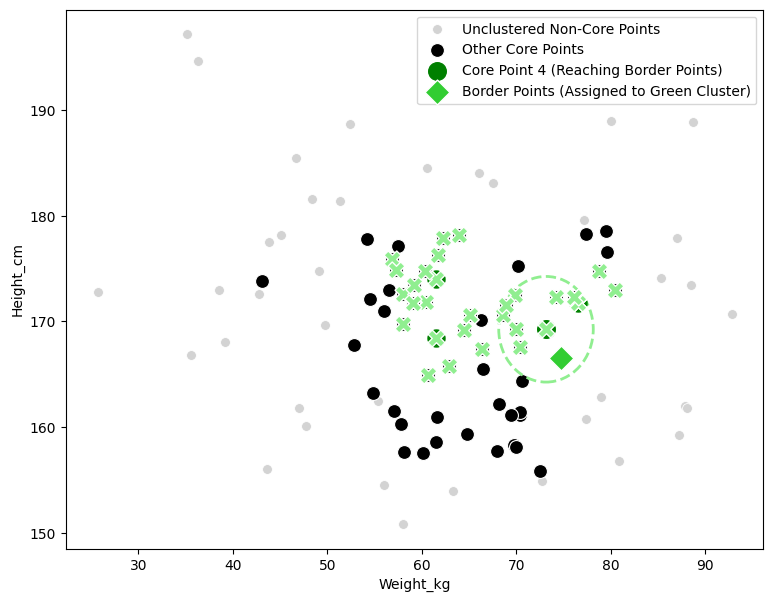

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt


# Select new core points from the identified core_points_df
# Let's pick un-clustered core points if possible or just another one.
new_center_point = df.loc[core_points_indices[2]]
new_center_point2 = df.loc[core_points_indices[3]]

# Calculate distances from the first new center point
distances_new_center_1 = np.sqrt(
    (df['Weight_kg'] - new_center_point['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point['Height_cm'])**2
)

# Calculate distances from the second new center point
distances_new_center_2 = np.sqrt(
    (df['Weight_kg'] - new_center_point2['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point2['Height_cm'])**2
)


# Identify points within the epsilon radius of the first center
within_eps_new_center_1 = distances_new_center_1 <= eps

# Identify core points that are also within the epsilon radius of the first center
overlapping_core_points_indices_1 = [idx for idx in core_points_indices
                                   if within_eps_new_center_1[idx]]
overlapping_core_points_df_1 = df.loc[overlapping_core_points_indices_1]

# Identify points within the epsilon radius of the second center
within_eps_new_center_2 = distances_new_center_2 <= eps

# Identify core points that are also within the epsilon radius of the second center
overlapping_core_points_indices_2 = [idx for idx in core_points_indices
                                   if within_eps_new_center_2[idx]]
overlapping_core_points_df_2 = df.loc[overlapping_core_points_indices_2]

# Plotting
plt.figure(figsize=(9, 7))

# All points (light gray background)
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray',
                s=50, label='Unclustered Non-Core Points')

# Plot existing core points (black)
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm',
                color='black', s=100, label='Other Core Points')

# Plot the first new selected core point (green)
plt.scatter(new_center_point['Weight_kg'], new_center_point['Height_cm'],
            color='green', s=150, zorder=5)

# Highlight the core points that are within the first new center's
# epsilon radius (light green)
sns.scatterplot(data=overlapping_core_points_df_1, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6)

# Plot the second new selected core point (blue)
plt.scatter(new_center_point2['Weight_kg'], new_center_point2['Height_cm'],
            color='green', s=150, zorder=5,)

# Highlight the core points that are within the second new center's
# epsilon radius (lightgreen)
sns.scatterplot(data=overlapping_core_points_df_2, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6)


# Select a third new core point
new_center_point3 = df.loc[core_points_indices[4]]

# Calculate distances from the third center point
distances_new_center_3 = np.sqrt(
    (df['Weight_kg'] - new_center_point3['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point3['Height_cm'])**2
)

# Identify points within the epsilon radius of the third center
within_eps_new_center_3 = distances_new_center_3 <= eps

# Identify core points within the third center's epsilon radius
overlapping_core_points_indices_3 = [
    idx for idx in core_points_indices if within_eps_new_center_3[idx]
]
overlapping_core_points_df_3 = df.loc[overlapping_core_points_indices_3]

# Plot the third selected core point (green)
plt.scatter(new_center_point3['Weight_kg'], new_center_point3['Height_cm'],
            color='green', s=150, zorder=5)


# Highlight core points within the third center's epsilon radius
sns.scatterplot(data=overlapping_core_points_df_3,
                x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6)


# Select a fourth core point (used to reach non-core / border points)
new_center_point4 = df.loc[core_points_indices[6]]
# Calculate distances from the fourth center point
distances_new_center_4 = np.sqrt(
    (df['Weight_kg'] - new_center_point4['Weight_kg'])**2 +
    (df['Height_cm'] - new_center_point4['Height_cm'])**2
)

# Points within epsilon radius
within_eps_new_center_4 = distances_new_center_4 <= eps

# Identify core points that are also within the epsilon radius of the second center
overlapping_core_points_indices_4 = [idx for idx in core_points_indices
                                   if within_eps_new_center_4[idx]]
overlapping_core_points_df_4 = df.loc[overlapping_core_points_indices_4]

# Identify NON-core points within epsilon → Border candidates
non_core_indices = list(set(df.index) - set(core_points_indices))

border_points_indices_4 = [
    idx for idx in non_core_indices if within_eps_new_center_4[idx]
]

border_points_df_4 = df.loc[border_points_indices_4]

# Plot the fourth core point (dark green)
plt.scatter(new_center_point4['Weight_kg'], new_center_point4['Height_cm'],
            color='green', s=160, zorder=6,
            label='Core Point 4 (Reaching Border Points)')

sns.scatterplot(data=overlapping_core_points_df_4, x='Weight_kg', y='Height_cm',
                color='lightgreen', s=150, marker='X',
                zorder=6)

# Draw epsilon circle around the fourth center
circle_new_4 = Circle(
    (new_center_point4['Weight_kg'], new_center_point4['Height_cm']),
    eps, fill=False, edgecolor='lightgreen',
    linewidth=2, linestyle='--'
)
plt.gca().add_patch(circle_new_4)

# Plot NON-core points that become BORDER points (assigned to green cluster)
sns.scatterplot(data=border_points_df_4,
                x='Weight_kg', y='Height_cm',
                color='limegreen', s=160, marker='D',
                zorder=7,
                label='Border Points (Assigned to Green Cluster)')

Non-core points are included in the cluster only if they lie within the ε-radius of at least one core point. If a non-core point’s ε-neighborhood does not overlap with any core point, it cannot be assigned to the cluster and is labeled as noise. Otherwise, it is classified as a border point and added to the cluster.

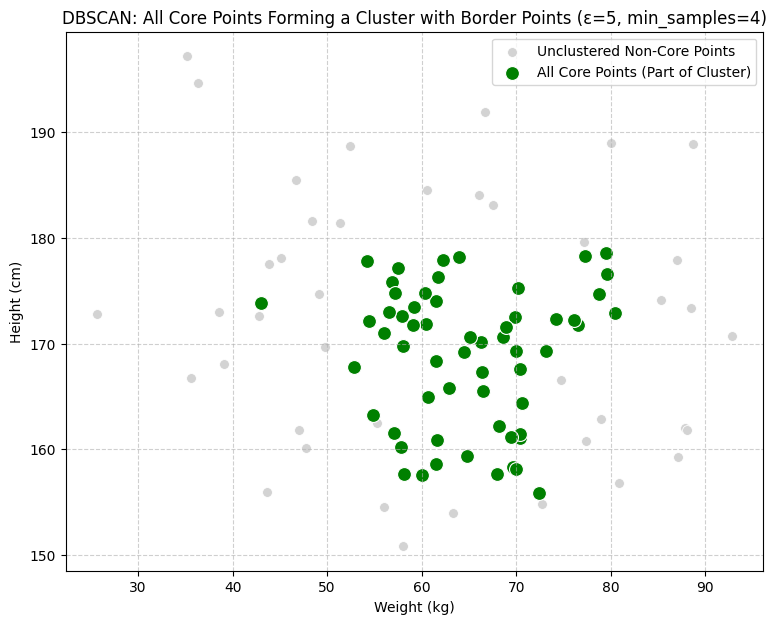

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

# All points (light gray background) that are NOT core points
non_core_df = df.drop(core_points_indices)
sns.scatterplot(data=non_core_df, x='Weight_kg', y='Height_cm', color='lightgray',
                s=50, label='Unclustered Non-Core Points')

# Plot all core points in green
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm',
                color='green', s=100, label='All Core Points (Part of Cluster)')

# Select a core point (new_center_point4 from previous cells) to demonstrate border points
# This point is already a core point and will be part of the green cluster.
# It's used here to illustrate how it connects to border points.
# We can explicitly highlight it for emphasis if needed,
# but it's covered by 'All Core Points'


plt.title(f'DBSCAN: All Core Points Forming a Cluster with Border Points (ε={eps}, min_samples={min_samples})')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Include a Non-Core Point to the first cluster if its circle overlaps at least one Core Point -> Border Point

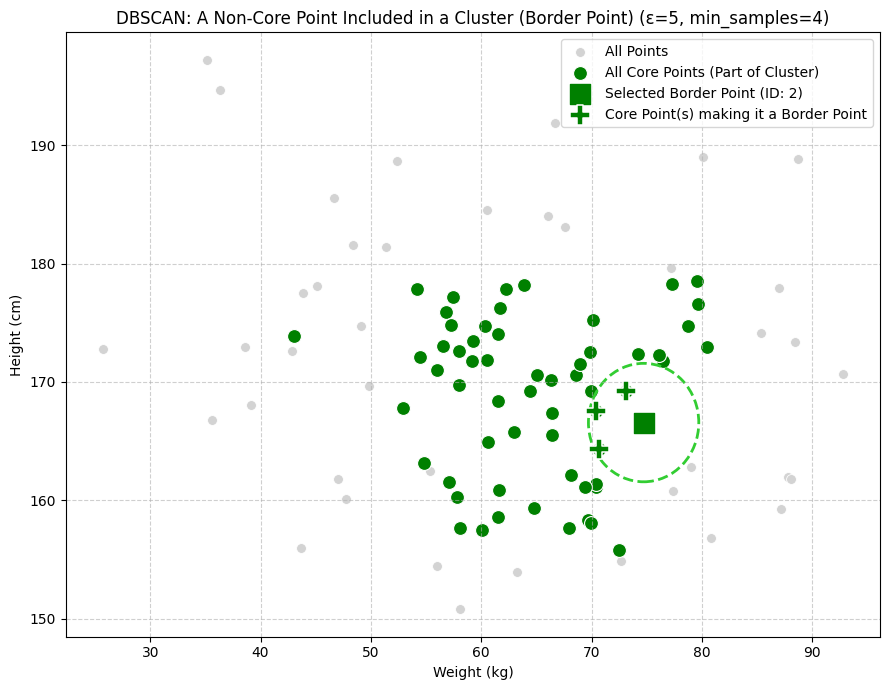

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to check if a non-core point is within epsilon of any core point
def is_neighbor_of_core(point_idx, df_data, core_indices, epsilon):
    p = df_data.loc[point_idx]
    for core_idx in core_indices:
        core_p = df_data.loc[core_idx]
        distance = np.sqrt(
            (p['Weight_kg'] - core_p['Weight_kg'])**2 +
            (p['Height_cm'] - core_p['Height_cm'])**2
        )
        if distance <= epsilon:
            return True
    return False

# `non_core_indices` and `core_points_indices` are available from previous cells

# Find a border candidate (non-core point within eps of a core point)
border_candidate_idx = -1
for idx in non_core_indices:
    if is_neighbor_of_core(idx, df, core_points_indices, eps):
        border_candidate_idx = idx
        break

if border_candidate_idx == -1:
    print("Could not find a suitable border point in the dataset.")
    # Fallback to a default if no border point is found - unlikely with this data
    border_candidate_idx = non_core_indices[0] if non_core_indices else 0

border_point = df.loc[border_candidate_idx]

plt.figure(figsize=(9, 7))

# Plot all points as light gray background
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray', s=50, label='All Points')

# Plot all core points in green
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm', color='green', s=100, label='All Core Points (Part of Cluster)')

# Highlight the selected Border Point
plt.scatter(border_point['Weight_kg'], border_point['Height_cm'],
            color='green', s=200, marker='s', zorder=5, label=f'Selected Border Point (ID: {border_candidate_idx})')

# Draw the epsilon circle around the Border Point
circle_border_point = Circle(
    (border_point['Weight_kg'], border_point['Height_cm']),
    eps, fill=False, edgecolor='limegreen', linewidth=2, linestyle='--'
)
plt.gca().add_patch(circle_border_point)

# Find and highlight the core point(s) that this border point neighbors
distances_to_border_point = np.sqrt(
    (df['Weight_kg'] - border_point['Weight_kg'])**2 +
    (df['Height_cm'] - border_point['Height_cm'])**2
)
core_neighbors_of_border = df.loc[[idx for idx in core_points_indices if distances_to_border_point[idx] <= eps]]
sns.scatterplot(data=core_neighbors_of_border, x='Weight_kg', y='Height_cm',
                color='green', s=200, marker='P', zorder=6,
                label='Core Point(s) making it a Border Point')

plt.title(f'DBSCAN: A Non-Core Point Included in a Cluster (Border Point) (ε={eps}, min_samples={min_samples})')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

A non-core point here only overlaps another Non-Core Point, even if it is included in the first cluster, not a Core Point, hence not a part of this cluster -> Noise Point

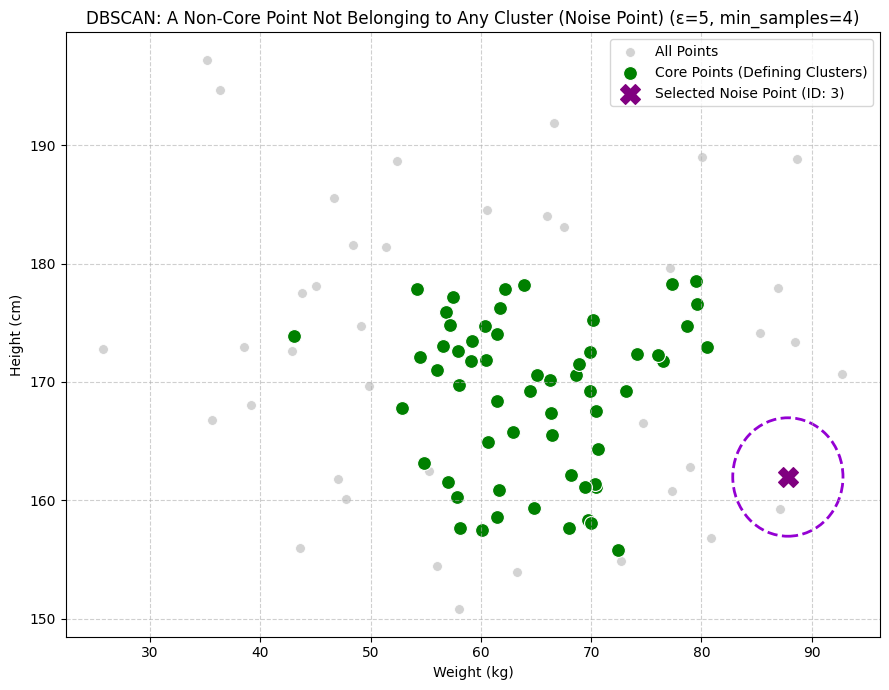

In [ ]:
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to check if a non-core point is within epsilon of any core point
def is_neighbor_of_core(point_idx, df_data, core_indices, epsilon):
    p = df_data.loc[point_idx]
    for core_idx in core_indices:
        core_p = df_data.loc[core_idx]
        distance = np.sqrt(
            (p['Weight_kg'] - core_p['Weight_kg'])**2 +
            (p['Height_cm'] - core_p['Height_cm'])**2
        )
        if distance <= epsilon:
            return True
    return False

# Identify non-core points
# `non_core_indices` is available from previous cells

# Find a noise candidate (non-core point not within eps of any core point)
noise_candidate_idx = -1
for idx in non_core_indices:
    if not is_neighbor_of_core(idx, df, core_points_indices, eps):
        # Also ensure it's not a core point itself (redundant if checking non_core_indices, but good for clarity)
        current_point_neighbors = count_neighbors_for_point(idx, df, eps)
        if current_point_neighbors < min_samples:
            noise_candidate_idx = idx
            break

# Fallback if no noise point found, though unlikely with current data
if noise_candidate_idx == -1:
    print("Could not find a suitable noise point in the dataset. Using a default.")
    # Attempt to find one that is truly isolated, if possible.
    # For demonstration, we'll just pick the first non-core point available
    # if the loop somehow didn't find one. This can happen if all non-core
    # points happen to be border points in a very dense dataset.
    noise_candidate_idx = non_core_indices[0] if non_core_indices else 0
    if is_neighbor_of_core(noise_candidate_idx, df, core_points_indices, eps):
        print(f"Warning: Default noise point (ID: {noise_candidate_idx}) might be a border point.")

noise_point = df.loc[noise_candidate_idx]

# Plotting
plt.figure(figsize=(9, 7))

# Plot all points as light gray background
sns.scatterplot(data=df, x='Weight_kg', y='Height_cm', color='lightgray', s=50, label='All Points')

# Plot all core points in green (as they define the clusters)
sns.scatterplot(data=core_points_df, x='Weight_kg', y='Height_cm', color='green', s=100, label='Core Points (Defining Clusters)')

# Highlight the selected Noise Point
plt.scatter(noise_point['Weight_kg'], noise_point['Height_cm'],
            color='purple', s=200, marker='X', zorder=5, label=f'Selected Noise Point (ID: {noise_candidate_idx})')

# Draw the epsilon circle around the Noise Point
circle_noise_point = Circle(
    (noise_point['Weight_kg'], noise_point['Height_cm']),
    eps, fill=False, edgecolor='darkviolet', linewidth=2, linestyle='--'
)
plt.gca().add_patch(circle_noise_point)

plt.title(f'DBSCAN: A Non-Core Point Not Belonging to Any Cluster (Noise Point) (ε={eps}, min_samples={min_samples})')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DBSCAN: Finalized

Manual cluster expansion (3 clusters)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

eps = 5          # radius
minPts = 4       # minimum points

def euclidean_distance(p1, p2):
    return np.sqrt(
        (p1['Weight_kg'] - p2['Weight_kg'])**2 +
        (p1['Height_cm'] - p2['Height_cm'])**2)

neighbors = {}

for i in df.index:
    neighbors[i] = [j for j in df.index
                    if euclidean_distance(df.loc[i], df.loc[j]) <= eps]

core_points = [i for i in neighbors if len(neighbors[i]) >= minPts]
non_core_points = [i for i in df.index if i not in core_points]

clusters = {}
visited = set()
cluster_id = 0

for point in core_points:
    if point in visited:
        continue

    cluster_id += 1
    clusters[cluster_id] = []
    stack = [point]

    while stack:
        current = stack.pop()

        if current in visited:
            continue

        visited.add(current)
        clusters[cluster_id].append(current)

        # Expand only from core points
        if current in core_points:
            for nb in neighbors[current]:
                if nb not in visited:
                    stack.append(nb)

    # Stop after forming 3 clusters
    if cluster_id == 3:
        break

Assign border points to nearest reachable cluster

In [ ]:
point_labels = {i: -1 for i in df.index}  # -1 = noise

for cid, points in clusters.items():
    for p in points:
        point_labels[p] = cid

for p in non_core_points:
    for cid, core_pts in clusters.items():
        for c in core_pts:
            if euclidean_distance(df.loc[p], df.loc[c]) <= eps:
                point_labels[p] = cid   # Border point
                break

df['cluster'] = df.index.map(point_labels)

Plot final DBSCAN result (by hand)

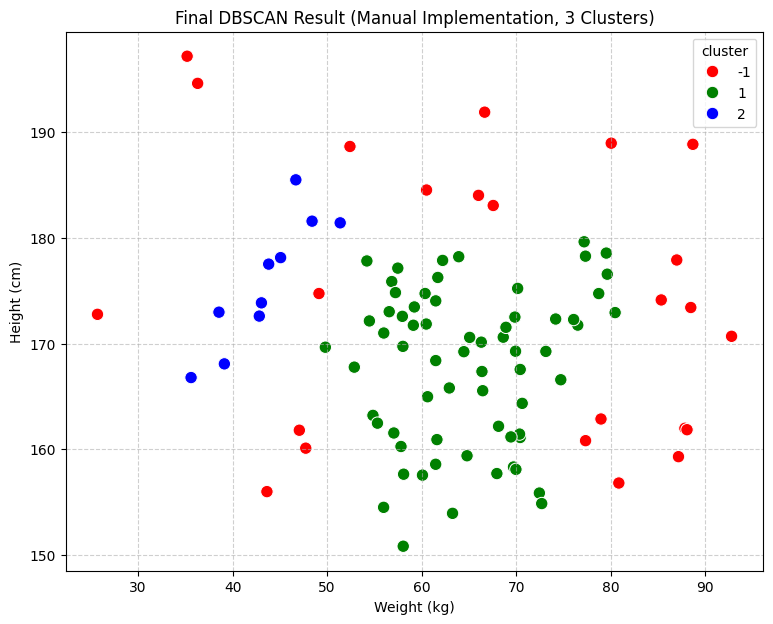

In [ ]:
plt.figure(figsize=(9, 7))

palette = {1: 'green', 2: 'blue', 3: 'purple', -1: 'red'}

sns.scatterplot(
    data=df,
    x='Weight_kg',
    y='Height_cm',
    hue='cluster',
    palette=palette,
    s=80
)

plt.title('Final DBSCAN Result (Manual Implementation, 3 Clusters)')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()